<a href="https://colab.research.google.com/github/quasarx-snips/devjams_lunap/blob/main/Module_1/ResNet_Hazard_Map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install -U segmentation-models-pytorch datasets huggingface_hub tqdm

import os, sys, random, time, math, glob, zipfile, requests
import numpy as np
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from tqdm.auto import tqdm

SEED = 95 #dont ask why
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #if on gcolab set it from runtime then t4gpu
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    print("Setting to cuDNN...")
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: None (Running on CPU)")

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Device:", device)




     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 795.8/795.8 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 14.2 MB/s eta 0:00:00
Setting to cuDNN...
GPU: Tesla T4
Python: 3.13.15
PyTorch: 2.11.0+cu128
Device: cuda


In [ ]:
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    CKPT_DIR = "/content/drive/MyDrive/lunap_hazard_checkpoints"
except Exception as e:
    CKPT_DIR = "/content/checkpoints"
    print("Drive mount skipped:", e)

os.makedirs(CKPT_DIR, exist_ok=True)
print("Checkpoint directory:", CKPT_DIR)


Mounted at /content/drive
Checkpoint directory: /content/drive/MyDrive/lunap_hazard_checkpoints


In [ ]:
from datasets import load_dataset

print("Loading crater dataset...")
crater_ds = load_dataset("gremlin97/crater_binary_segmentation")
print(crater_ds)
for split in ("train", "val", "test"):
    if split in crater_ds:
        print(f"{split:>5}: {len(crater_ds[split]):,} samples")


Loading crater dataset...


README.md:   0%|          | 0.00/1.61k [00:00<?, ?B/s]

data/train-00000-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  356MB            

data/train-00000-of-00002.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  355MB            

...

data/val-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/3600 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/900 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/900 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'mask', 'width', 'height', 'class_labels'],
        num_rows: 3600
    })
    test: Dataset({
        features: ['image', 'mask', 'width', 'height', 'class_labels'],
        num_rows: 900
    })
    val: Dataset({
        features: ['image', 'mask', 'width', 'height', 'class_labels'],
        num_rows: 900
    })
})
train: 3,600 samples
  val: 900 samples
 test: 900 samples


In [ ]:
import os
import zipfile
from pathlib import Path
import requests
from tqdm import tqdm

# Use local Colab SSD for heavy I/O to avoid Google Drive FUSE bottlenecks
DATA_ROOT = "/content/data"
os.makedirs(DATA_ROOT, exist_ok=True)

DOORS_URL = "https://zenodo.org/records/7107409/files/DOORS.zip?download=1"
DOORS_ZIP = os.path.join(DATA_ROOT, "DOORS.zip")
DOORS_DIR = os.path.join(DATA_ROOT, "DOORS")

if not os.path.isdir(DOORS_DIR) or not any(Path(DOORS_DIR).rglob("*")):
    if not os.path.exists(DOORS_ZIP):
        print("Downloading DOORS (~2.7 GB) to local SSD...")
        with requests.get(DOORS_URL, stream=True, timeout=30) as r:
            r.raise_for_status()
            total = int(r.headers.get("content-length", 0))
            with open(DOORS_ZIP, "wb") as f:
                with tqdm(total=total, unit="B", unit_scale=True, desc="DOORS.zip") as pbar:
                    for chunk in r.iter_content(chunk_size=8 * 1024 * 1024):
                        if chunk:
                            f.write(chunk)
                            pbar.update(len(chunk))

    print("Extracting DOORS (this may take a few minutes)...")
    os.makedirs(DOORS_DIR, exist_ok=True)
    with zipfile.ZipFile(DOORS_ZIP, "r") as z:
        members = z.infolist()
        with tqdm(total=len(members), desc="Extracting DOORS") as pbar:
            for member in members:
                z.extract(member, DOORS_DIR)
                pbar.update(1)
    os.remove(DOORS_ZIP)

print("DOORS ready at:", DOORS_DIR)

DOORS.zip: 100%|██████████| 2.70G/2.70G [15:39<00:00, 2.88MB/s]


Extracting DOORS (this may take a few minutes)...


Extracting DOORS:  36%|███▌      | 169850/477866 [00:27<00:53, 5789.67it/s]

In [ ]:
from pathlib import Path
import os

IMG_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}

def image_files(folder):
    try:
        return [str(p) for p in Path(folder).iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS]
    except Exception:
        return []

doors_path = Path(DOORS_DIR)
print(f"Scanning {doors_path} for image and mask folders...")

all_img_dirs = []
all_mask_dirs = []

# Globally search every directory in the extracted tree
for p in doors_path.rglob("*"):
    if p.is_dir():
        name = p.name.lower()
        files = image_files(p)
        if len(files) > 0:
            if any(k in name for k in ["mask", "masks", "label", "labels", "gt", "seg"]):
                all_mask_dirs.append((str(p), len(files)))
            elif any(k in name for k in ["img", "image", "images"]):
                all_img_dirs.append((str(p), len(files)))

print("Found image directories:", len(all_img_dirs))
print("Found mask directories:", len(all_mask_dirs))

if not all_img_dirs or not all_mask_dirs:
    raise RuntimeError("DOORS dataset files are missing or incomplete. Try re-extracting locally to /content/data instead of Google Drive.")

# Sort to pick the largest available split
all_img_dirs.sort(key=lambda x: x[1], reverse=True)
all_mask_dirs.sort(key=lambda x: x[1], reverse=True)

BOULDER_IMG_DIR = all_img_dirs[0][0]
BOULDER_MASK_DIR = all_mask_dirs[0][0]

def norm_stem(path):
    s = Path(path).stem.lower()
    for token in ("_mask", "-mask", "_label", "-label", "_gt", "-gt", "_seg", "-seg"):
        s = s.replace(token, "")
    return s

img_paths = image_files(BOULDER_IMG_DIR)
mask_paths = image_files(BOULDER_MASK_DIR)

mask_by_key = {norm_stem(p): p for p in mask_paths}
pairs = [(p, mask_by_key[norm_stem(p)]) for p in img_paths if norm_stem(p) in mask_by_key]

if len(pairs) < 100:
    raise RuntimeError(f"Only {len(pairs)} valid image/mask pairs matched. Check if the dataset extracted correctly.")

print(f"Matched {len(pairs):,} boulder image/mask pairs")
print("Images:", BOULDER_IMG_DIR)
print("Masks :", BOULDER_MASK_DIR)
print("Example:", pairs[0])

Scanning /content/data/DOORS for image and mask folders...
Found image directories: 10
Found mask directories: 2
Matched 45,269 boulder image/mask pairs
Images: /content/data/DOORS/DOORS/Segmentation/DS1/DS/img
Masks : /content/data/DOORS/DOORS/Segmentation/DS1/DS/mask
Example: ('/content/data/DOORS/DOORS/Segmentation/DS1/DS/img/TR_015598.png', '/content/data/DOORS/DOORS/Segmentation/DS1/DS/mask/TR_015598.png')


In [ ]:
IMG_SIZE = 256
NUM_CLASSES = 3
BACKGROUND, CRATER, BOULDER = 0, 1, 2
IGNORE_INDEX = 255

MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def binary_mask(mask):
    return (np.asarray(mask) > 0).astype(np.uint8)

def resize_pair(image, mask, size=IMG_SIZE):
    image = np.asarray(Image.fromarray(image).resize((size, size), Image.Resampling.BILINEAR))
    mask = np.asarray(Image.fromarray(mask).resize((size, size), Image.Resampling.NEAREST))
    return image, mask

def augment_pair(image, mask, training=True):
    if training:
        if random.random() < 0.5:
            image, mask = np.fliplr(image).copy(), np.fliplr(mask).copy()
        if random.random() < 0.5:
            image, mask = np.flipud(image).copy(), np.flipud(mask).copy()
        if random.random() < 0.5:
            k = random.randint(1, 3)
            image, mask = np.rot90(image, k).copy(), np.rot90(mask, k).copy()

        if random.random() < 0.35:
            scale = random.uniform(0.85, 1.15)
            bias = random.uniform(-12, 12)
            image = np.clip(image.astype(np.float32) * scale + bias, 0, 255).astype(np.uint8)

        if random.random() < 0.20:
            noise = np.random.normal(0, 4, image.shape).astype(np.float32)
            image = np.clip(image.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    image = image.astype(np.float32) / 255.0
    image = (image - MEAN) / STD
    image = torch.from_numpy(image.transpose(2, 0, 1)).float()
    mask = torch.from_numpy(mask.astype(np.int64)).long()
    return image, mask

class CraterDataset(Dataset):
    def __init__(self, hf_split, training=False):
        self.ds = hf_split
        self.training = training

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]
        image = np.asarray(item["image"].convert("RGB"))
        mask = binary_mask(item["mask"])
        image, mask = resize_pair(image, mask)
        mask = mask * CRATER

        # Only background/crater are known in this source.
        # Boulder is deliberately not treated as a negative label.
        return (*augment_pair(image, mask, self.training), "crater")

class BoulderDataset(Dataset):
    def __init__(self, pairs, training=False):
        self.pairs = pairs
        self.training = training

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        image_path, mask_path = self.pairs[idx]
        image = np.asarray(Image.open(image_path).convert("RGB"))
        mask = binary_mask(Image.open(mask_path).convert("L"))
        image, mask = resize_pair(image, mask)
        mask = mask * BOULDER
        return (*augment_pair(image, mask, self.training), "boulder")

# Reproducible, disjoint boulder train/validation split.
rng = np.random.default_rng(SEED)
indices = rng.permutation(len(pairs))
n_val = max(1, int(0.10 * len(indices)))

val_idx = indices[:n_val]
train_idx = indices[n_val:]

boulder_train_pairs = [pairs[i] for i in train_idx]
boulder_val_pairs = [pairs[i] for i in val_idx]

crater_train = CraterDataset(crater_ds["train"], training=True)
crater_val = CraterDataset(crater_ds["val"], training=False)
boulder_train = BoulderDataset(boulder_train_pairs, training=True)
boulder_val = BoulderDataset(boulder_val_pairs, training=False)

train_dataset = ConcatDataset([crater_train, boulder_train])
val_dataset = ConcatDataset([crater_val, boulder_val])

BATCH_SIZE = 8 if device.type == "cuda" else 2
NUM_WORKERS = 2 if device.type == "cuda" else 0

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0), drop_last=True
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0)
)

print(f"Train samples: {len(train_dataset):,}")
print(f"Val samples  : {len(val_dataset):,}")
print(f"Batch size   : {BATCH_SIZE}")


Train samples: 44,343
Val samples  : 5,426
Batch size   : 8


In [ ]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None,
).to(device)

CE_WEIGHTS = torch.tensor([1.0, 4.0, 4.0], device=device)
ce = nn.CrossEntropyLoss(weight=CE_WEIGHTS)

def binary_dice(logits, targets, positive_class):
    prob = torch.softmax(logits, dim=1)[:, positive_class]
    true = (targets == positive_class).float()

    smooth = 1.0
    intersection = (prob * true).sum()
    return 1.0 - (2.0 * intersection + smooth) / (
        prob.sum() + true.sum() + smooth
    )

def criterion(logits, targets, sources):
    # Source-specific binary objectives avoid contradictory labels.
    ce_terms = []
    dice_terms = []

    for source, positive in (("crater", CRATER), ("boulder", BOULDER)):
        idx = [i for i, s in enumerate(sources) if s == source]
        if not idx:
            continue

        idx = torch.tensor(idx, device=logits.device)
        src_logits = logits.index_select(0, idx)
        src_targets = targets.index_select(0, idx)

        # For each source, collapse the task to background vs its own hazard.
        binary_target = (src_targets == positive).long()
        binary_logits = torch.stack(
            [src_logits[:, BACKGROUND], src_logits[:, positive]], dim=1
        )

        ce_terms.append(nn.functional.cross_entropy(
            binary_logits, binary_target,
            weight=torch.tensor([1.0, 4.0], device=logits.device)
        ))
        dice_terms.append(binary_dice(src_logits, src_targets, positive))

    return 0.5 * torch.stack(ce_terms).mean() + 0.5 * torch.stack(dice_terms).mean()

@torch.no_grad()
def batch_metrics(logits, targets, sources):
    pred = logits.argmax(1)
    result = {}

    for source, cls in (("crater", CRATER), ("boulder", BOULDER)):
        idx = [i for i, s in enumerate(sources) if s == source]
        if not idx:
            continue

        idx = torch.tensor(idx, device=logits.device)
        p = pred.index_select(0, idx)
        t = targets.index_select(0, idx)

        tp = ((p == cls) & (t == cls)).sum().item()
        fn = ((p != cls) & (t == cls)).sum().item()
        fp = ((p == cls) & (t != cls)).sum().item()

        result[source] = {
            "recall": tp / max(tp + fn, 1),
            "iou": tp / max(tp + fn + fp, 1),
        }

    return result

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6
)
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

print(f" Model ready: {sum(p.numel() for p in model.parameters())/1e6:.1f}M parameters")


In [ ]:
images, masks, sources = next(iter(train_loader))
print("CPU batch:", images.shape, masks.shape, sources[:4])

images = images.to(device, non_blocking=True)
masks = masks.to(device, non_blocking=True)

model.eval()
with torch.no_grad():
    logits = model(images)
    test_loss = criterion(logits, masks, list(sources))

print("Logits:", logits.shape)
print("Loss:", float(test_loss))
assert logits.shape[1] == 3
assert logits.shape[-2:] == masks.shape[-2:]
print("Smoke test passed.")


In [ ]:
MAX_EPOCHS = 25
PATIENCE = 7

last_ckpt = os.path.join(CKPT_DIR, "last.pt")
best_ckpt = os.path.join(CKPT_DIR, "best.pt")

start_epoch = 0
best_val_loss = float("inf")
bad_epochs = 0

def save_checkpoint(path, epoch):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "best_val_loss": best_val_loss,
        "bad_epochs": bad_epochs,
        "config": {
            "img_size": IMG_SIZE,
            "num_classes": NUM_CLASSES,
            "encoder": "resnet34",
        },
    }, path)

# Only this notebook's checkpoint schema is accepted.
if os.path.exists(last_ckpt):
    try:
        state = torch.load(last_ckpt, map_location=device, weights_only=False)
        model.load_state_dict(state["model_state_dict"])
        optimizer.load_state_dict(state["optimizer_state_dict"])
        scheduler.load_state_dict(state["scheduler_state_dict"])
        if "scaler_state_dict" in state:
            scaler.load_state_dict(state["scaler_state_dict"])

        start_epoch = int(state["epoch"]) + 1
        best_val_loss = float(state.get("best_val_loss", float("inf")))
        bad_epochs = int(state.get("bad_epochs", 0))
        print(f"Resumed from epoch {start_epoch}; best val={best_val_loss:.5f}")
    except Exception as e:
        print("Old/incompatible checkpoint detected:", e)
        print("Starting fresh.")
        start_epoch, best_val_loss, bad_epochs = 0, float("inf"), 0

for epoch in range(start_epoch, MAX_EPOCHS):
    t0 = time.time()

    # ---------- TRAIN ----------
    model.train()
    train_sum, seen = 0.0, 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{MAX_EPOCHS} TRAIN")
    for images, masks, sources in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            logits = model(images)
            loss = criterion(logits, masks, list(sources))

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        bs = images.size(0)
        train_sum += loss.item() * bs
        seen += bs
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    train_loss = train_sum / max(seen, 1)

    # ---------- VALIDATION ----------
    model.eval()
    val_sum, val_seen = 0.0, 0
    metrics = {
        "crater": {"recall": [], "iou": []},
        "boulder": {"recall": [], "iou": []},
    }

    with torch.no_grad():
        for images, masks, sources in tqdm(val_loader, desc=f"Epoch {epoch+1}/{MAX_EPOCHS} VAL"):
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                logits = model(images)
                loss = criterion(logits, masks, list(sources))

            bs = images.size(0)
            val_sum += loss.item() * bs
            val_seen += bs

            m = batch_metrics(logits, masks, list(sources))
            for src in m:
                metrics[src]["recall"].append(m[src]["recall"])
                metrics[src]["iou"].append(m[src]["iou"])

    val_loss = val_sum / max(val_seen, 1)
    scheduler.step(val_loss)

    cr = float(np.mean(metrics["crater"]["recall"]))
    ci = float(np.mean(metrics["crater"]["iou"]))
    br = float(np.mean(metrics["boulder"]["recall"]))
    bi = float(np.mean(metrics["boulder"]["iou"]))

    improved = val_loss < best_val_loss

    if improved:
        best_val_loss = val_loss
        bad_epochs = 0
        save_checkpoint(best_ckpt, epoch)
        tag = " BEST"
    else:
        bad_epochs += 1
        tag = ""

    save_checkpoint(last_ckpt, epoch)

    mins = (time.time() - t0) / 60
    lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch+1:03d} | train={train_loss:.4f} | val={val_loss:.4f} | "
        f"crater R={cr:.3f} IoU={ci:.3f} | "
        f"boulder R={br:.3f} IoU={bi:.3f} | "
        f"lr={lr:.2e} | {mins:.1f} min{tag}"
    )

    if bad_epochs >= PATIENCE:
        print(f"Early stopping after {PATIENCE} non-improving epochs.")
        break

print("Best checkpoint:", best_ckpt)
print("Last checkpoint:", last_ckpt)


In [ ]:
if not os.path.exists(best_ckpt):
    raise FileNotFoundError(f"No best model found at {best_ckpt}. Train first.")

state = torch.load(best_ckpt, map_location=device, weights_only=False)

if "model_state_dict" not in state:
    raise RuntimeError("Incompatible checkpoint. Train with this notebook's training cell.")

model.load_state_dict(state["model_state_dict"])
model.eval()

print(f"Loaded best model from epoch {state['epoch'] + 1}")
print(f"Best validation loss: {state['best_val_loss']:.5f}")


Saving 0cc9d2af-0409-46af-9721-e3c2843b1f57.jpg to 0cc9d2af-0409-46af-9721-e3c2843b1f57 (1).jpg
Input: 0cc9d2af-0409-46af-9721-e3c2843b1f57 (1).jpg
Resolution: 1123 × 829
Running tiled inference...


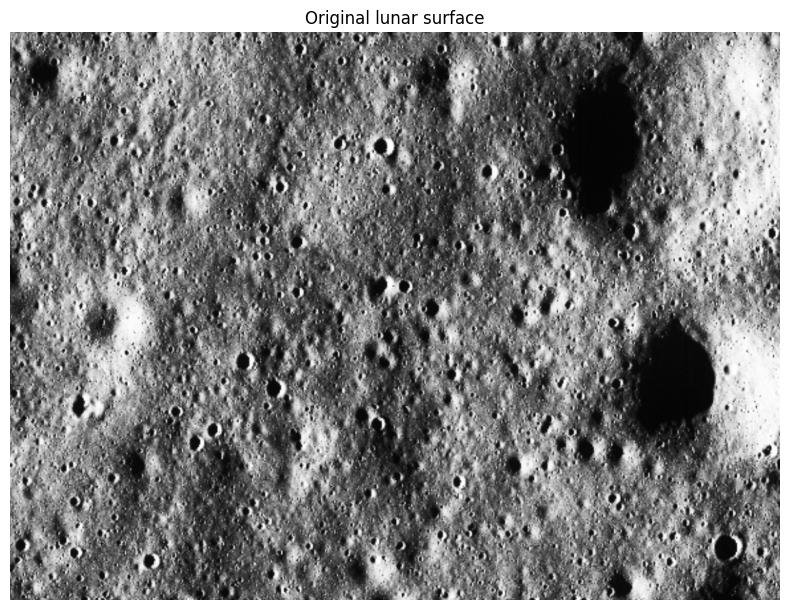

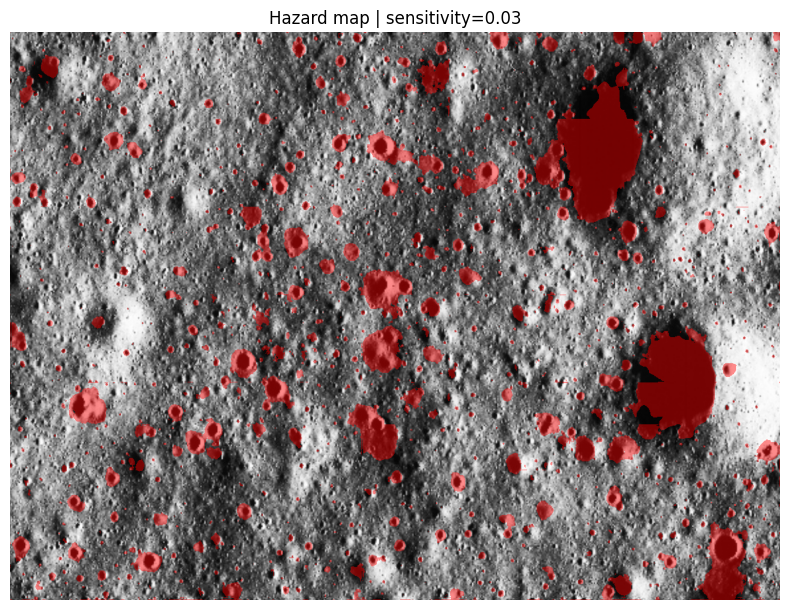

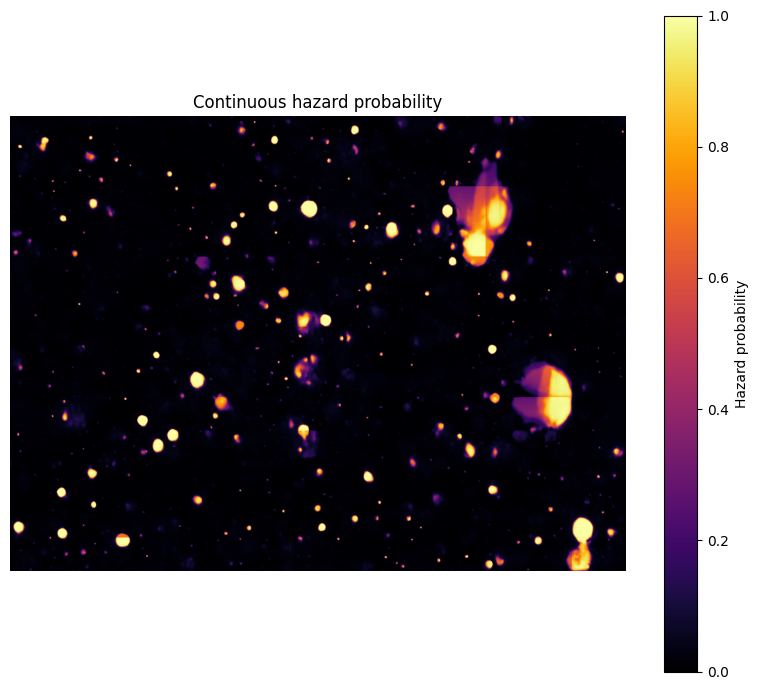


========== HAZARD SUMMARY ==========
Crater pixels : 13.12%
Boulder pixels: 0.00%
Risky pixels  : 13.12%
Red = crater | Orange = boulder


In [ ]:
import matplotlib.pyplot as plt
from google.colab import files

# -------- USER SETTINGS --------
SENSITIVITY = 0.01  # lower = more sensitive; higher = stricter
TILE_SIZE = IMG_SIZE
OVERLAP = 0.50
TILE_BATCH = 8 if device.type == "cuda" else 2
# -------------------------------

def preprocess_tile(tile):
    arr = tile.astype(np.float32) / 255.0
    arr = (arr - MEAN) / STD
    return torch.from_numpy(arr.transpose(2, 0, 1)).float()

@torch.no_grad()
def tiled_predict(image_rgb, tile_size=TILE_SIZE, overlap=OVERLAP, batch_size=TILE_BATCH):
    h, w = image_rgb.shape[:2]

    pad_h = max(0, tile_size - h)
    pad_w = max(0, tile_size - w)
    if pad_h or pad_w:
        padded = np.pad(
            image_rgb,
            ((0, pad_h), (0, pad_w), (0, 0)),
            mode="reflect"
        )
    else:
        padded = image_rgb

    ph, pw = padded.shape[:2]
    stride = max(1, int(tile_size * (1.0 - overlap)))

    ys = list(range(0, max(ph - tile_size, 0) + 1, stride))
    xs = list(range(0, max(pw - tile_size, 0) + 1, stride))

    if not ys or ys[-1] != ph - tile_size:
        ys.append(max(ph - tile_size, 0))
    if not xs or xs[-1] != pw - tile_size:
        xs.append(max(pw - tile_size, 0))

    prob_sum = np.zeros((3, ph, pw), dtype=np.float32)
    weight_sum = np.zeros((ph, pw), dtype=np.float32)

    yy, xx = np.mgrid[0:tile_size, 0:tile_size]
    center = (tile_size - 1) / 2
    sigma = tile_size * 0.35
    weight = np.exp(-((xx-center)**2 + (yy-center)**2) / (2*sigma**2)).astype(np.float32)
    weight = np.maximum(weight, 0.05)

    batch_tiles, locations = [], []

    def flush():
        nonlocal batch_tiles, locations
        if not batch_tiles:
            return

        x = torch.stack(batch_tiles).to(device, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            p = torch.softmax(model(x), dim=1).float().cpu().numpy()

        for j, (y, x0) in enumerate(locations):
            prob_sum[:, y:y+tile_size, x0:x0+tile_size] += p[j] * weight
            weight_sum[y:y+tile_size, x0:x0+tile_size] += weight

        batch_tiles, locations = [], []

    for y in ys:
        for x0 in xs:
            tile = padded[y:y+tile_size, x0:x0+tile_size]
            batch_tiles.append(preprocess_tile(tile))
            locations.append((y, x0))

            if len(batch_tiles) >= batch_size:
                flush()

    flush()

    return prob_sum[:, :h, :w] / np.maximum(weight_sum[None, :h, :w], 1e-6)

uploaded = files.upload()
if not uploaded:
    raise RuntimeError("No image uploaded.")

img_path = next(iter(uploaded.keys()))
orig = np.asarray(Image.open(img_path).convert("RGB"))
h, w = orig.shape[:2]

print(f"Input: {img_path}")
print(f"Resolution: {w} × {h}")
print("Running tiled inference...")

probs = tiled_predict(orig)

crater_prob = probs[CRATER]
boulder_prob = probs[BOULDER]
risk_prob = np.maximum(crater_prob, boulder_prob)

crater_mask = crater_prob >= SENSITIVITY
boulder_mask = boulder_prob >= SENSITIVITY

# Resolve pixels where both hazard probabilities cross threshold.
class_map = np.zeros((h, w), dtype=np.uint8)
class_map[crater_mask & (crater_prob >= boulder_prob)] = CRATER
class_map[boulder_mask & (boulder_prob > crater_prob)] = BOULDER

overlay = orig.astype(np.float32).copy()

cr = class_map == CRATER
bo = class_map == BOULDER

overlay[cr] = 0.55 * overlay[cr] + 0.45 * np.array([255, 0, 0], dtype=np.float32)
overlay[bo] = 0.55 * overlay[bo] + 0.45 * np.array([255, 165, 0], dtype=np.float32)
overlay = np.clip(overlay, 0, 255).astype(np.uint8)

np.save("/content/hazard_probability.npy", risk_prob.astype(np.float32))
np.save("/content/hazard_class_map.npy", class_map)

plt.figure(figsize=(8, 7))
plt.imshow(orig)
plt.title("Original lunar surface")
plt.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 7))
plt.imshow(overlay)
plt.title(f"Hazard map | sensitivity={SENSITIVITY:.2f}")
plt.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 7))
plt.imshow(risk_prob, cmap="inferno", vmin=0, vmax=1)
plt.colorbar(label="Hazard probability")
plt.title("Continuous hazard probability")
plt.axis("off")
plt.tight_layout()
plt.show()

print()
print("========== HAZARD SUMMARY ==========")
print(f"Crater pixels : {cr.mean()*100:.2f}%")
print(f"Boulder pixels: {bo.mean()*100:.2f}%")
print(f"Risky pixels  : {(cr|bo).mean()*100:.2f}%")
print("Red = crater | Orange = boulder")


In [ ]:
# Human-readable overlay.
Image.fromarray(overlay).save("/content/hazard_overlay.png")

# RGB class visualization.
rgb_map = np.zeros((h, w, 3), dtype=np.uint8)
rgb_map[class_map == CRATER] = [255, 0, 0]
rgb_map[class_map == BOULDER] = [255, 165, 0]
Image.fromarray(rgb_map).save("/content/hazard_classes_rgb.png")

# 0=safe, 1=crater, 2=boulder (stored as raw uint8).
Image.fromarray(class_map).save("/content/hazard_class_map.png")

print("Saved:")
print("  /content/hazard_overlay.png")
print("  /content/hazard_classes_rgb.png")
print("  /content/hazard_class_map.png")
print("  /content/hazard_probability.npy")
